# 04 — Recall vs end-task answer quality (WS4)

**Feeds C6** — *"where recall stops predicting end-task answer quality"*, the
abstract's most novel claim and the last one without data. Side deliverable:
the WS3 winning-combo run at 10M (`results/ws3/*_10m.csv`).

Design: `results/recall-vs-quality.md`.
Every verdict below is keyed to its **§7 PRE-REGISTERED INTERPRETATION**,
committed before any data existed.

This notebook does the **question filter and draw**, the **operating-point
rule**, and every **committed CSV and chart**. The heavy work runs as scripts:

| step | script | needs |
|---|---|---|
| 0 | `scripts/recall-quality/build_ws4_filter.py` — passage cache + answer-presence flags | nothing |
| 1 | `scripts/recall-quality/run_ws4_milvus.py` — index rebuilds, truncation arms at 10M, gates, WS3 sweeps, WS4 retrieval (~18 h) | `make up` |
| 2 | `scripts/recall-quality/run_ws4_generate.py <arms>` — generation + blind judge, checkpointed, $75 governor | `ANTHROPIC_API_KEY` |
| 3 | `scripts/recall-quality/run_ws4_rejudge.py` — judge reliability re-run | step 2 |

Cells whose inputs have not landed print `PENDING` and skip; re-run the
notebook as caches arrive. The final execution must show no `PENDING`.
Runtime of the notebook itself: minutes (10k-resample bootstraps).

In [1]:
# ---- setup ------------------------------------------------------------------
import json, sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from benchlib import manifest
from benchlib.recall_quality import core
from benchlib.config import *  # pinned constants — single source of truth
from benchlib.quantization import recall_at_k
from benchlib.agent_harness import load_checkpoint

OUT = ws4_dir(); OUT.mkdir(parents=True, exist_ok=True)
CACHE = ws4_cache(); RET = CACHE / "retrieval"
WS3_OUT = RESULTS_DIR / "ws3"
WS3_CACHE_10 = DATA_DIR / "ws3_cache" / WS4_SCALE
N_ROWS = SLICES[WS4_SCALE]

q_all = pd.read_parquet(DATA_DIR / "queries_ws4.parquet")
ws4_gt = np.load(gt_path(WS4_SCALE))["ws4_indices"]
assert len(q_all) == ws4_gt.shape[0] == 3610
PENDING = []
def pending(what):
    PENDING.append(what); print(f"PENDING: {what}")
print(f"WS4 at {WS4_SCALE}: {len(q_all)} validation questions, GT top-{ws4_gt.shape[1]}")

WS4 at 10m: 3610 validation questions, GT top-100


## 1. The question filter (spec §3.1) and the draw (§3.2–3.3)

Answer-presence@100 of every validation question against its **exact**
top-100. The filter rate is the measure of NQ-vs-2023-snapshot drift and is
quoted, not hidden. The draw is seeded and committed **before** any arm
retrieves for these questions; re-running this cell must reproduce it exactly.

In [2]:
# ---- results/ws4/question_filter.csv — the ONLY cell that writes it ---------
flags = pd.read_parquet(CACHE / "question_flags.parquet")
assert len(flags) == 3610 and (flags.row.to_numpy() == np.arange(3610)).all()
n_pass = int(flags.answer_presence_at_100.sum())
pass_set = flags[flags.answer_presence_at_100]
qf = pd.DataFrame([dict(
    scale=WS4_SCALE, n_validation=len(flags), n_pass_at_100=n_pass,
    filter_rate=n_pass / len(flags),
    answer_presence_at_10_all=flags.answer_presence_at_10.mean(),
    answer_presence_at_10_pass_set=pass_set.answer_presence_at_10.mean(),
    ws1_train_sample_estimate_at_100=0.677,
    ground_truth="gt_10m_top100.npz ws4_indices (exact fp32 IP, fp64-verified)",
    normaliser="benchlib.recall_quality.core.norm_text (== notebook 01 cell 5d)")])
qf.to_csv(OUT / "question_filter.csv", index=False)
manifest.record(OUT / "question_filter.csv")
print(qf.T.to_string(header=False))

scale                                                                                      10m
n_validation                                                                              3610
n_pass_at_100                                                                             2597
filter_rate                                                                           0.719391
answer_presence_at_10_all                                                             0.579778
answer_presence_at_10_pass_set                                                         0.80593
ws1_train_sample_estimate_at_100                                                         0.677
ground_truth                      gt_10m_top100.npz ws4_indices (exact fp32 IP, fp64-verified)
normaliser                                     benchlib.recall_quality.core.norm_text (== notebook 01 cell 5d)


In [3]:
# ---- results/ws4/questions.csv — the ONLY cell that writes it ---------------
main_idx, sanity_idx = core.select_questions(
    flags.answer_presence_at_100.to_numpy(), WS4_N_MAIN, WS4_N_SANITY, SEED)
rows = []
for subset, idxs in (("main", main_idx), ("sanity", sanity_idx)):
    for r in idxs:
        rows.append(dict(
            row=int(r), subset=subset, question=q_all.question.iloc[r],
            golds=json.dumps([str(a) for a in q_all.answer.iloc[r]]),
            answer_presence_at_10_gt=bool(flags.answer_presence_at_10.iloc[r]),
            answer_presence_at_100_gt=bool(flags.answer_presence_at_100.iloc[r])))
qdf = pd.DataFrame(rows)
if (OUT / "questions.csv").exists():
    prior = pd.read_csv(OUT / "questions.csv")
    assert prior.row.tolist() == qdf.row.tolist(), (
        "the committed draw changed — the seed, the filter or the flags moved")
qdf.to_csv(OUT / "questions.csv", index=False)
manifest.record(OUT / "questions.csv", {"seed": SEED, "n_main": WS4_N_MAIN,
                                         "n_sanity": WS4_N_SANITY})
for p in ("answer_prompt.txt", "judge_prompt.txt"):
    manifest.record(OUT / p)
print(f"main {len(main_idx)} (all pass@100: {qdf[qdf.subset=='main'].answer_presence_at_100_gt.all()}), "
      f"sanity {len(sanity_idx)} (pass@100 fraction "
      f"{qdf[qdf.subset=='sanity'].answer_presence_at_100_gt.mean():.2f}); "
      f"main answer-presence@10 on exact GT: {qdf[qdf.subset=='main'].answer_presence_at_10_gt.mean():.3f}")
qdf.head(3)

main 450 (all pass@100: True), sanity 50 (pass@100 fraction 0.62); main answer-presence@10 on exact GT: 0.822


,row,subset,question,golds,answer_presence_at_10_gt,answer_presence_at_100_gt
0,14,main,who does the voice of nala in the lion king,"[""Niketa Calame"", ""Sally Dworsky"", ""Moira Kell...",True,True
1,19,main,what age do you need to be to buy a bb gun,"[""18""]",True,True
2,30,main,when was the first hunger games book published,"[""September 14, 2008"", ""2008""]",True,True


## 2. Arms and the operating-point rule (spec §4.1–4.3)

Three families: **truncation** (own 10M collections, served at nprobe=512),
**quantization** (`pq_m256`, `rabitq` at their quantizer ceilings on the shared
collection), **pruning** (the reference SQ8 index at lower nprobe, plus the
brief's `refine_k2@64`, whose loss at that point is pruning). The pruning
nprobe for each target is the SQ8 GT-sweep point nearest that target's
GT-sweep recall (ties → higher nprobe). GT numbers *choose* the point; the
chart's x is re-measured on the WS4 questions.

In [4]:
# ---- results/ws4/sq8_low_nprobe_sweep_10m.csv — the ONLY cell that writes it -
low_f = CACHE / "sq8_low_nprobe_sweep.json"
if low_f.exists():
    low = pd.DataFrame(json.loads(low_f.read_text()))
    low.to_csv(OUT / "sq8_low_nprobe_sweep_10m.csv", index=False)
    manifest.record(OUT / "sq8_low_nprobe_sweep_10m.csv")
    print(low[["sweep_value", "recall_at_10", "recall_at_100", "n_recall_queries"]].to_string(index=False))
else:
    pending("sq8 low-nprobe GT sweep (run_ws4_milvus.py sq8)")

 sweep_value  recall_at_10  recall_at_100  n_recall_queries
           1       0.55595       0.446723             10000
           2       0.67808       0.579113             10000
           4       0.77454       0.693920             10000
           8       0.84607       0.788729             10000


In [5]:
# ---- results/ws4/arms.csv — the ONLY cell that writes it --------------------
ws2_10 = pd.read_csv(RESULTS_DIR / "ws2" / "curves_10m.csv")
sq8_rows = ws2_10[ws2_10.arm == "ivf_sq8"].set_index("sweep_value")
trunc_caches = {a: WS3_CACHE_10 / f"{a}.json" for a in WS4_TRUNC_ARMS}
if low_f.exists() and all(p.exists() for p in trunc_caches.values()):
    sweep = {int(n): float(r) for n, r in sq8_rows.recall_at_10.items()}
    sweep.update({int(r.sweep_value): float(r.recall_at_10) for r in low.itertuples()})
    sweep_n = {int(n): int(r) for n, r in sq8_rows.n_recall_queries.items()}
    sweep_n.update({int(r.sweep_value): int(r.n_recall_queries) for r in low.itertuples()})
    def gt_r10(arm_rows, nprobe):
        r = [x for x in arm_rows if x["sweep_value"] == nprobe][0]
        return float(r["recall_at_10"]), int(r["n_recall_queries"])
    arms = []
    def add(key, arm, family, index, nprobe, r10, n, chosen_by, target_arm=None,
            target_recall=None, refine_k=None, dim=EMBED_DIM):
        arms.append(dict(arm_key=key, arm=arm, family=family, index=index, dim=dim,
                         nprobe=nprobe, refine_k=refine_k, gt_sweep_recall_at_10=r10,
                         gt_sweep_n_queries=n, chosen_by=chosen_by,
                         target_arm=target_arm, target_recall=target_recall))
    r, n = sweep[512], sweep_n[512]
    add("sq8_np512", "sq8@512", "reference", "IVF_SQ8", 512, r, n, "spec 4.1 reference")
    targets = {}
    for a, (t, d) in WS4_TRUNC_ARMS.items():
        rows_a = json.loads(trunc_caches[a].read_text())["rows"]
        r, n = gt_r10(rows_a, WS4_TRUNC_NPROBE)
        add(f"{a}_np{WS4_TRUNC_NPROBE}", f"{a}@{WS4_TRUNC_NPROBE}", "truncation",
            "IVF_SQ8", WS4_TRUNC_NPROBE, r, n, "spec 4.3 ceiling point", dim=d)
        targets[a] = r
    for key, arm, ws2arm, extra in (("pq_np256", "pq_m256@256", "ivf_pq_m256", {}),
                                    ("rabitq_np256", "rabitq@256", "rabitq", {})):
        row = ws2_10[(ws2_10.arm == ws2arm) & (ws2_10.sweep_value == WS4_QUANT_NPROBE)].iloc[0]
        add(key, arm, "quantization", row.index_type, WS4_QUANT_NPROBE,
            float(row.recall_at_10), int(row.n_recall_queries), "spec 4.1 quantizer ceiling")
        if ws2arm == "ivf_pq_m256":
            targets["pq_np256"] = float(row.recall_at_10)
    row = ws2_10[(ws2_10.arm == "rabitq_refine_sq8_k2") & (ws2_10.sweep_value == WS4_REFINE_NPROBE)].iloc[0]
    add("refine_np64", "refine_k2@64", "pruning", "IVF_RABITQ+SQ8 refine", WS4_REFINE_NPROBE,
        float(row.recall_at_10), int(row.n_recall_queries), "spec 4.1 the brief's pair partner",
        refine_k=2)
    picks = {}
    for target_arm, tr in targets.items():
        p = core.pick_matching_nprobe(tr, sweep)
        picks[target_arm] = p
        key = f"sq8_np{p}"
        if key in {a["arm_key"] for a in arms}:
            for a in arms:
                if a["arm_key"] == key:
                    a["target_arm"] += f"; {target_arm}"
            continue
        add(key, f"sq8@{p}", "pruning", "IVF_SQ8", p, sweep[p], sweep_n[p],
            "spec 4.3 nearest GT-sweep recall", target_arm=target_arm, target_recall=tr)
    add("parametric", "parametric", "none", "none", None, None, None, "spec 5.5 leak floor", dim=None)
    arms_df = pd.DataFrame(arms)
    arms_df.to_csv(OUT / "arms.csv", index=False)
    manifest.record(OUT / "arms.csv")
    print(arms_df[["arm_key", "family", "nprobe", "gt_sweep_recall_at_10", "chosen_by", "target_arm"]].to_string(index=False))
    print("\npruning picks:", picks)
else:
    pending("arms.csv needs the sq8 low sweep and all three truncation-arm 10M caches")

             arm_key       family  nprobe  gt_sweep_recall_at_10                         chosen_by     target_arm
           sq8_np512    reference   512.0                0.99166                spec 4.1 reference            NaN
pca_uc_512_sq8_np512   truncation   512.0                0.96303            spec 4.3 ceiling point            NaN
pca_uc_384_sq8_np512   truncation   512.0                0.91524            spec 4.3 ceiling point            NaN
   mrl_512_sq8_np512   truncation   512.0                0.75386            spec 4.3 ceiling point            NaN
            pq_np256 quantization   256.0                0.81941        spec 4.1 quantizer ceiling            NaN
        rabitq_np256 quantization   256.0                0.77763        spec 4.1 quantizer ceiling            NaN
         refine_np64      pruning    64.0                0.96015 spec 4.1 the brief's pair partner            NaN
            sq8_np64      pruning    64.0                0.96516  spec 4.3 nearest GT-sw

## 3. The WS3 winning-combo run at 10M (spec §4.4)

`pca_uc_512_sq8`, `pca_uc_384_sq8`, `mrl_512_sq8` on fresh 10M collections
(one forced compaction, then frozen — the WS2 10M protocol), full nprobe sweep
over the 10k GT queries, measured footprint. Denominator: analytic raw fp32
bytes at 1024d (WS2 Decision 1). Gates G1 (offline ceiling vs 1M) and G2
(Milvus vs its own ceiling) are recorded per arm.

In [6]:
# ---- results/ws3/curves_10m.csv — the ONLY cell that writes it --------------
RAW_1024_BYTES_10 = N_ROWS * EMBED_DIM * 4
if all(p.exists() for p in trunc_caches.values()):
    rows = []
    for a, p in trunc_caches.items():
        rows.extend(json.loads(p.read_text())["rows"])
    curves_10 = pd.DataFrame(rows)
    curves_10["payload_compression_vs_1024_fp32"] = 4 * EMBED_DIM / curves_10.nominal_payload_bytes
    curves_10["footprint_compression_vs_raw_1024"] = RAW_1024_BYTES_10 / curves_10.loaded_bytes
    curves_10["dim_compression"] = EMBED_DIM / curves_10.dim
    curves_10.to_csv(WS3_OUT / "curves_10m.csv", index=False)
    manifest.record(WS3_OUT / "curves_10m.csv")
    print(curves_10.groupby("arm", sort=False).agg(
        points=("sweep_value", "size"), best_r10=("recall_at_10", "max"),
        loaded_GiB=("loaded_bytes", lambda b: b.iloc[0] / 2**30),
        footprint_x=("footprint_compression_vs_raw_1024", "first")).round(3))
else:
    pending("WS3 10M curves need all three truncation-arm caches")

                points  best_r10  loaded_GiB  footprint_x
arm                                                      
pca_uc_512_sq8       6     0.963       5.539        6.887
pca_uc_384_sq8       6     0.915       4.276        8.922
mrl_512_sq8          6     0.754       5.539        6.887


In [7]:
# ---- results/ws3/dim_verdict_10m.csv — the ONLY cell that writes it ---------
if all(p.exists() for p in trunc_caches.values()):
    v1m = pd.read_csv(WS3_OUT / "dim_verdict_1m.csv").set_index("arm")
    rows = []
    for a in WS4_TRUNC_ARMS:
        g = curves_10[curves_10.arm == a]
        best = g.loc[g.recall_at_10.idxmax()]
        g1 = json.loads((CACHE / f"gate_g1_{a}.json").read_text())
        g2 = json.loads((CACHE / f"gate_g2_{a}.json").read_text())
        rows.append(dict(
            arm=a, transform=best["transform"], dim=int(best.dim), quantizer="sq8",
            best_recall_at_10=best.recall_at_10, best_recall_at_100=best.recall_at_100,
            at_nprobe=int(best.sweep_value),
            recall_loss_vs_full_dim_gt=1 - best.recall_at_10,
            ceiling_10m_first_n=g1["ceiling_10m_first_n"], ceiling_n_queries=g1["n_queries"],
            ceiling_1m=g1["ceiling_1m"], gate_g1_passed=g1["passed"],
            milvus_vs_ceiling_first_n=g2["milvus_recall_at_10"], gate_g2_passed=g2["passed"],
            best_recall_at_10_1m=float(v1m.loc[a, "best_recall_at_10"]),
            delta_vs_1m=best.recall_at_10 - float(v1m.loc[a, "best_recall_at_10"]),
            single_digit_loss=bool(best.recall_at_10 >= 0.90),
            loaded_GiB=best.loaded_bytes / 2**30,
            footprint_compression_vs_raw_1024=best.footprint_compression_vs_raw_1024,
            footprint_compression_vs_flat_1024_1m=float(v1m.loc[a, "footprint_compression_vs_flat_1024"]),
            payload_compression_vs_1024_fp32=best.payload_compression_vs_1024_fp32,
            p50_ms_at_best=best.p50_ms, qps_at_best=best.qps,
            build_seconds=best.build_seconds, ingest_seconds=best.ingest_seconds,
            n_rows=int(best.n_rows), scale=WS4_SCALE))
    verdict_10 = pd.DataFrame(rows)
    verdict_10.to_csv(WS3_OUT / "dim_verdict_10m.csv", index=False)
    manifest.record(WS3_OUT / "dim_verdict_10m.csv")
    print(verdict_10[["arm", "best_recall_at_10", "best_recall_at_10_1m", "delta_vs_1m",
                      "ceiling_10m_first_n", "ceiling_1m", "footprint_compression_vs_raw_1024",
                      "single_digit_loss", "qps_at_best"]].round(4).to_string(index=False))
else:
    pending("WS3 10M verdict")

           arm  best_recall_at_10  best_recall_at_10_1m  delta_vs_1m  ceiling_10m_first_n  ceiling_1m  footprint_compression_vs_raw_1024  single_digit_loss  qps_at_best
pca_uc_512_sq8             0.9630                0.9599       0.0031               0.9666      0.9637                             6.8873               True      44.1745
pca_uc_384_sq8             0.9152                0.9089       0.0064               0.9158      0.9110                             8.9222               True      65.9456
   mrl_512_sq8             0.7539                0.6995       0.0544               0.7503      0.7004                             6.8873              False      41.6107


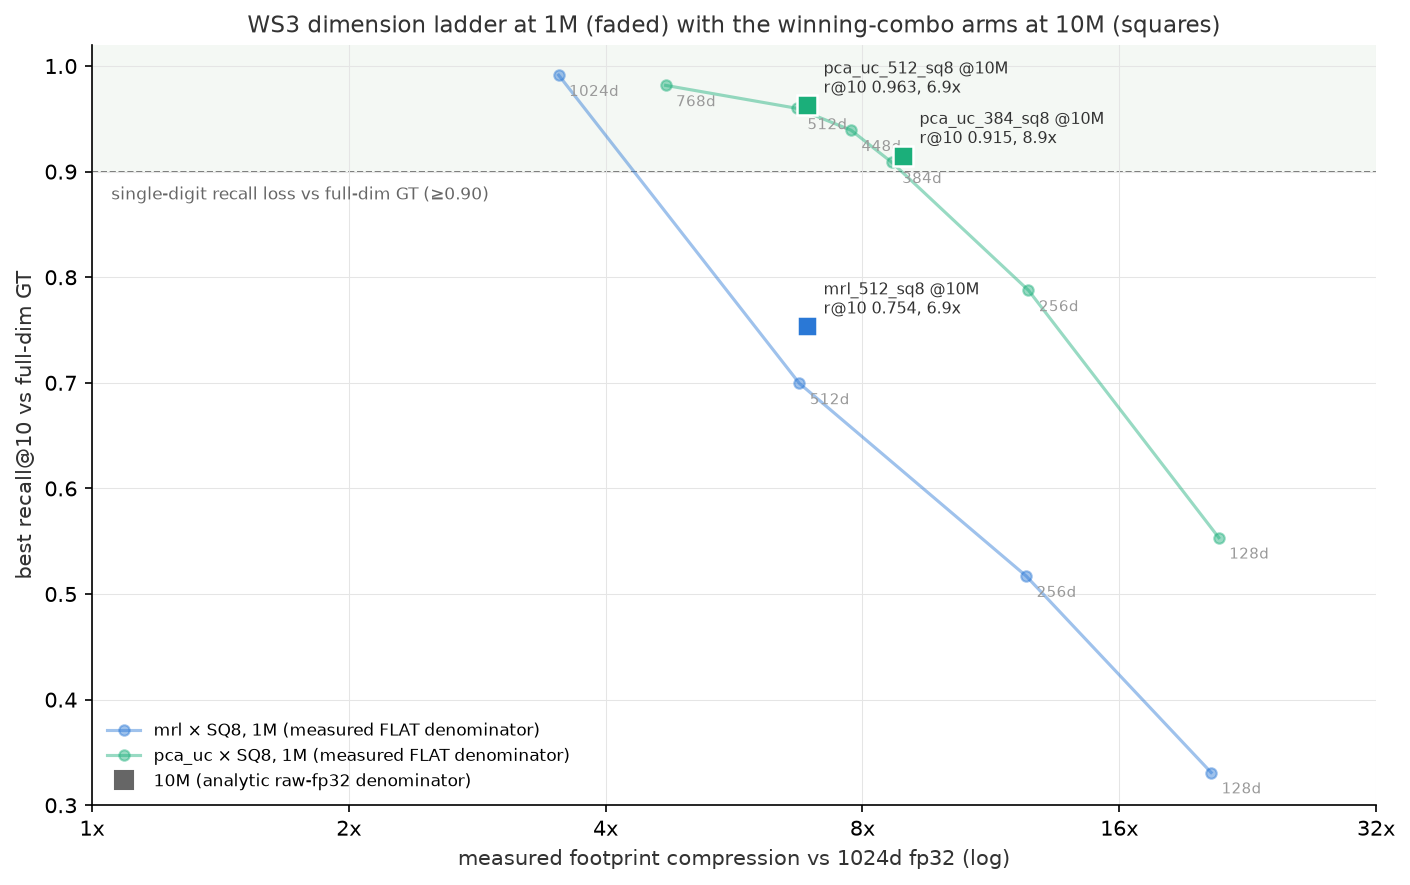

In [8]:
# ---- results/ws3/chart_recall_vs_compression_1m_10m.png ---------------------
TRANSFORM_COLOR = {"mrl": "#2a78d6", "pca_uc": "#1baf7a"}
INK, INK2, GRID, REF = "#333333", "#666666", "#e5e5e5", "#999999"
if all(p.exists() for p in trunc_caches.values()):
    v1 = pd.read_csv(WS3_OUT / "dim_verdict_1m.csv")
    v1 = v1[(v1.quantizer == "sq8") & v1["transform"].isin(TRANSFORM_COLOR)]
    fig, ax = plt.subplots(figsize=(9.5, 6), dpi=150)
    ax.axhspan(0.90, 1.02, color="#f4f8f4", zorder=0)
    ax.axhline(0.90, color=INK2, lw=0.8, ls="--", zorder=1)
    ax.text(0.015, 0.886, "single-digit recall loss vs full-dim GT (≥0.90)", ha="left", va="top",
            color=INK2, fontsize=8, transform=ax.get_yaxis_transform())
    for t, c in TRANSFORM_COLOR.items():
        g = v1[v1["transform"] == t].sort_values("dim")
        ax.plot(g.footprint_compression_vs_flat_1024, g.best_recall_at_10, "-o", color=c,
                lw=1.5, ms=5, alpha=0.45, zorder=3, label=f"{t} × SQ8, 1M (measured FLAT denominator)")
        for _, r in g.iterrows():
            ax.annotate(f"{int(r.dim)}d", (r.footprint_compression_vs_flat_1024, r.best_recall_at_10),
                        textcoords="offset points", xytext=(5, -10), fontsize=7, color=REF)
    for _, r in verdict_10.iterrows():
        c = TRANSFORM_COLOR[r["transform"]]
        ax.plot(r.footprint_compression_vs_raw_1024, r.best_recall_at_10, "s", color=c, ms=10,
                markeredgecolor="white", markeredgewidth=1.2, zorder=5)
        ax.annotate(f"{r.arm} @10M\nr@10 {r.best_recall_at_10:.3f}, {r.footprint_compression_vs_raw_1024:.1f}x",
                    (r.footprint_compression_vs_raw_1024, r.best_recall_at_10),
                    textcoords="offset points", xytext=(8, 6), fontsize=7.5, color=INK)
    ax.plot([], [], "s", color=INK2, ms=9, label="10M (analytic raw-fp32 denominator)")
    ax.set_xscale("log", base=2); ax.set_xticks([1, 2, 4, 8, 16, 32])
    ax.set_xticklabels([f"{t}x" for t in [1, 2, 4, 8, 16, 32]])
    ax.set_xlabel("measured footprint compression vs 1024d fp32 (log)", color=INK)
    ax.set_ylabel("best recall@10 vs full-dim GT", color=INK)
    ax.set_ylim(0.3, 1.02); ax.grid(True, color=GRID, lw=0.5, zorder=0)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.legend(frameon=False, fontsize=8, loc="lower left")
    ax.set_title("WS3 dimension ladder at 1M (faded) with the winning-combo arms at 10M (squares)",
                 color=INK, fontsize=11)
    fig.tight_layout(); fig.savefig(WS3_OUT / "chart_recall_vs_compression_1m_10m.png"); plt.show()
else:
    pending("WS3 1M+10M chart")

## 4. The runs (spec §5) — assembled from the checkpoint

`scripts/recall-quality/run_ws4_generate.py` writes `data/ws4_cache/runs_checkpoint.jsonl`;
this cell turns it into `results/ws4/runs.csv` and checks completeness against
`arms.csv` × `questions.csv`. Gate G4: the reference arm's recall@10 on the
main questions must be ≥ 0.97.

In [9]:
# ---- results/ws4/runs.csv — the ONLY cell that writes it --------------------
from benchlib.recall_quality.runner import CHECKPOINT
ck = load_checkpoint(CHECKPOINT)
if ck and (OUT / "arms.csv").exists():
    runs = pd.DataFrame(list(ck.values()))
    runs["qid"] = runs.qid.astype(int)
    arms_df = pd.read_csv(OUT / "arms.csv")
    expected_arms = arms_df.arm_key.tolist()
    n_q = len(qdf)
    counts = runs.groupby("arm").size()
    status = pd.DataFrame({"arm_key": expected_arms}).assign(
        rows=lambda d: d.arm_key.map(counts).fillna(0).astype(int), expected=n_q)
    status["complete"] = status.rows == status.expected
    complete_arms = status[status.complete].arm_key.tolist()
    extra = sorted(set(runs.arm) - set(expected_arms))
    assert not extra, f"checkpoint rows for arms not in arms.csv: {extra}"
    assert (runs.cache_read_input_tokens == 0).all() and (runs.cache_creation_input_tokens == 0).all()
    runs = runs.merge(qdf[["row", "answer_presence_at_10_gt"]], left_on="qid", right_on="row", how="left").drop(columns="row")
    runs = runs.sort_values(["arm", "qid"]).reset_index(drop=True)
    runs.to_csv(OUT / "runs.csv", index=False)
    manifest.record(OUT / "runs.csv")
    spend = runs.cost_total_billed.sum()
    print(status.to_string(index=False))
    print(f"\n{len(runs)} rows; {len(complete_arms)}/{len(expected_arms)} arms complete; "
          f"spend ${spend:.2f} (gen ${runs.cost_gen_usd.sum():.2f} + judge ${runs.cost_judge_usd.sum():.2f})")
    if "sq8_np512" in complete_arms:
        ref_r = runs[(runs.arm == "sq8_np512") & (runs.subset == "main")].recall_at_10.mean()
        assert ref_r >= WS4_GATE_G4_MIN_RECALL, f"G4 FAILED: reference recall on main = {ref_r:.4f}"
        print(f"G4 PASSED: reference recall@10 on main = {ref_r:.4f}")
    if not status.complete.all():
        pending("generation incomplete for: " + ", ".join(status[~status.complete].arm_key))
else:
    complete_arms = []
    pending("no generation checkpoint yet (or arms.csv missing)")

             arm_key  rows  expected  complete
           sq8_np512   500       500      True
pca_uc_512_sq8_np512   500       500      True
pca_uc_384_sq8_np512   500       500      True
   mrl_512_sq8_np512   500       500      True
            pq_np256   500       500      True
        rabitq_np256   500       500      True
         refine_np64   500       500      True
            sq8_np64   500       500      True
            sq8_np16   500       500      True
             sq8_np4   500       500      True
             sq8_np8   500       500      True
          parametric   500       500      True

6000 rows; 12/12 arms complete; spend $50.17 (gen $24.56 + judge $25.62)
G4 PASSED: reference recall@10 on main = 0.9920


In [10]:
# ---- per-question matrices over the MAIN set, complete arms only ------------
def matrices(subset):
    sub = runs[(runs.subset == subset) & runs.arm.isin(complete_arms)]
    piv = lambda col: sub.pivot(index="qid", columns="arm", values=col).sort_index()
    R, Qj = piv("recall_at_10"), piv("judge_correct").astype(float)
    EM, F1, AP = piv("em").astype(float), piv("f1"), piv("answer_presence_at_10")
    if "parametric" in R:
        R["parametric"] = np.nan; AP["parametric"] = np.nan
    return R, Qj, EM, F1, AP.astype(float)
if complete_arms:
    R, QJ, EM, F1, AP = matrices("main")
    assert not QJ.isna().any().any(), "a complete arm has missing judge rows"
    ret_arms = [a for a in complete_arms if a != "parametric"]
    print(f"main matrix: {QJ.shape[0]} questions × {QJ.shape[1]} arms")
    print(pd.DataFrame({"recall": R[ret_arms].mean(), "judge": QJ[ret_arms].mean(),
                        "ap@10": AP[ret_arms].mean(), "em": EM[ret_arms].mean(),
                        "f1": F1[ret_arms].mean()}).round(4).sort_values("recall", ascending=False))

main matrix: 450 questions × 12 arms
                      recall   judge   ap@10      em      f1
arm                                                         
sq8_np512             0.9920  0.4978  0.8178  0.2533  0.3413
sq8_np64              0.9691  0.4800  0.8067  0.2400  0.3250
refine_np64           0.9673  0.4956  0.8067  0.2556  0.3476
pca_uc_512_sq8_np512  0.9642  0.4867  0.8133  0.2444  0.3383
pca_uc_384_sq8_np512  0.9231  0.4844  0.8089  0.2400  0.3288
sq8_np16              0.9184  0.4711  0.7978  0.2356  0.3235
sq8_np8               0.8660  0.4800  0.7822  0.2356  0.3220
pq_np256              0.8171  0.4933  0.8000  0.2556  0.3440
sq8_np4               0.8007  0.4356  0.7378  0.2156  0.2985
rabitq_np256          0.7811  0.4778  0.7911  0.2533  0.3400
mrl_512_sq8_np512     0.7576  0.4689  0.7889  0.2289  0.3216


## 5. The x-axis rule (spec §6.1) — recall measured on the WS4 questions

Per arm: recall@10 over the 450 main questions against `ws4_indices`, its
paired-bootstrap CI, the GT-sweep number that *chose* the operating point,
and the difference. The GT number never appears on the chart.

In [11]:
# ---- results/ws4/recall_on_ws4_questions.csv — the ONLY cell that writes it -
if complete_arms and ret_arms:
    idx = core.bootstrap_indices(len(R), WS4_N_BOOTSTRAP, SEED)
    rows = []
    for a in ret_arms:
        m = json.loads(str(np.load(RET / f"{a}.npz")["meta"]))
        b = core.boot_means(R[a].to_numpy(), idx)
        lo, hi = core.percentile_ci(b, WS4_PAIR_ALPHA)
        gt = arms_df.set_index("arm_key").loc[a, "gt_sweep_recall_at_10"]
        rows.append(dict(arm_key=a, family=arms_df.set_index("arm_key").loc[a, "family"],
                         recall_ws4_main=R[a].mean(), recall_ci_lo=lo, recall_ci_hi=hi,
                         recall_ws4_all3610=m["ws4_recall_at_10_all3610"],
                         recall_gt_sweep=gt, delta_ws4_minus_gt=R[a].mean() - gt, n_main=len(R)))
    rec = pd.DataFrame(rows).sort_values("recall_ws4_main", ascending=False)
    rec.to_csv(OUT / "recall_on_ws4_questions.csv", index=False)
    manifest.record(OUT / "recall_on_ws4_questions.csv")
    print(rec.round(4).to_string(index=False))
else:
    pending("recall on WS4 questions")

             arm_key       family  recall_ws4_main  recall_ci_lo  recall_ci_hi  recall_ws4_all3610  recall_gt_sweep  delta_ws4_minus_gt  n_main
           sq8_np512    reference           0.9920        0.9893        0.9944              0.9919           0.9917              0.0003     450
            sq8_np64      pruning           0.9691        0.9629        0.9751              0.9650           0.9652              0.0040     450
         refine_np64      pruning           0.9673        0.9602        0.9742              0.9594           0.9602              0.0072     450
pca_uc_512_sq8_np512   truncation           0.9642        0.9593        0.9689              0.9602           0.9630              0.0012     450
pca_uc_384_sq8_np512   truncation           0.9231        0.9162        0.9300              0.9132           0.9152              0.0079     450
            sq8_np16      pruning           0.9184        0.9064        0.9300              0.9000           0.9018              0.0167 

## 6. Spec §7.1 — the knee

Per arm, `Δ = Q(ref) − Q(arm)` with a paired-bootstrap CI, classified
**DROP** (CI excludes zero from above), **PLATEAU** (a loss ≥ 0.05 is ruled
out), else **INCONCLUSIVE**. `r*` = the lowest measured recall such that
every arm at or above it is PLATEAU. Branches K1/K2/K3 as written in the spec.
Judge accuracy is primary; EM, F1 and answer-presence@10 run through the same
classification as secondary rows.

In [12]:
# ---- results/ws4/summary.csv + slopes.csv — the ONLY cell that writes them --
REF = "sq8_np512"
if complete_arms and REF in complete_arms:
    fam = arms_df.set_index("arm_key").family
    recall_d = {a: R[a].to_numpy() for a in ret_arms}
    summ, slopes = [], []
    for metric, M in (("judge", QJ), ("em", EM), ("f1", F1), ("answer_presence_at_10", AP)):
        qual = {a: M[a].to_numpy() for a in ret_arms}
        s = core.summarise_arms(recall_d, qual, ref=REF, n_boot=WS4_N_BOOTSTRAP, seed=SEED,
                               margin=WS4_EQUIVALENCE_MARGIN, alpha=WS4_PAIR_ALPHA)
        for r in s:
            r.update(metric=metric, family=fam[r["arm"]])
        summ += s
        for r in core.adjacent_slopes(recall_d, qual, n_boot=WS4_N_BOOTSTRAP, seed=SEED, alpha=WS4_PAIR_ALPHA):
            r.update(metric=metric); slopes.append(r)
        if "parametric" in complete_arms:
            pm = M["parametric"].to_numpy()
            b = core.boot_means(pm, core.bootstrap_indices(len(pm), WS4_N_BOOTSTRAP, SEED))
            lo, hi = core.percentile_ci(b, WS4_PAIR_ALPHA)
            summ.append(dict(arm="parametric", n=len(pm), recall=np.nan, recall_ci_lo=np.nan,
                             recall_ci_hi=np.nan, quality=pm.mean(), quality_ci_lo=lo, quality_ci_hi=hi,
                             delta_vs_ref=np.nan, delta_ci_lo=np.nan, delta_ci_hi=np.nan,
                             **{"class": "floor"}, metric=metric, family="none"))
    summary = pd.DataFrame(summ).sort_values(["metric", "recall"], ascending=[True, False])
    summary.to_csv(OUT / "summary.csv", index=False)
    manifest.record(OUT / "summary.csv")
    slopes_df = pd.DataFrame(slopes)
    slopes_df.to_csv(OUT / "slopes.csv", index=False)
    manifest.record(OUT / "slopes.csv")
    J = summary[(summary.metric == "judge") & (summary.arm != REF) & (summary.arm != "parametric")]
    knee_arms = [(r.arm, r.recall, r["class"]) for _, r in J.iterrows()]
    K = core.knee_branch(knee_arms); r_star = core.knee(knee_arms)
    print(summary[summary.metric == "judge"][["arm", "family", "recall", "quality", "quality_ci_lo",
          "quality_ci_hi", "delta_vs_ref", "delta_ci_lo", "delta_ci_hi", "class"]].round(4).to_string(index=False))
    print(f"\n§7.1 verdict (judge): branch {K}; r* = {r_star}")
    print("\nsecondary classes:")
    print(summary[summary.arm != REF].pivot(index="arm", columns="metric", values="class").to_string())
    if len(slopes_df):
        print("\nadjacent slopes (judge):")
        print(slopes_df[slopes_df.metric == "judge"].round(3).to_string(index=False))
else:
    pending("§7.1 needs the reference arm complete")

                 arm       family  recall  quality  quality_ci_lo  quality_ci_hi  delta_vs_ref  delta_ci_lo  delta_ci_hi     class
           sq8_np512    reference  0.9920   0.4978         0.4511         0.5444        0.0000       0.0000       0.0000 reference
            sq8_np64      pruning  0.9691   0.4800         0.4333         0.5267        0.0178      -0.0022       0.0378   PLATEAU
         refine_np64      pruning  0.9673   0.4956         0.4511         0.5422        0.0022      -0.0200       0.0244   PLATEAU
pca_uc_512_sq8_np512   truncation  0.9642   0.4867         0.4422         0.5333        0.0111      -0.0133       0.0356   PLATEAU
pca_uc_384_sq8_np512   truncation  0.9231   0.4844         0.4400         0.5311        0.0133      -0.0133       0.0400   PLATEAU
            sq8_np16      pruning  0.9184   0.4711         0.4244         0.5178        0.0267       0.0022       0.0511      DROP
             sq8_np8      pruning  0.8660   0.4800         0.4356         0.5267   

## 7. Spec §7.2 — the mechanism, at matched measured recall

Pairs A–F. Pair A is primary at the face-value CI; B–F count toward M1 only at
the Bonferroni width (α/5). A pair is *matched* only if its measured recalls
sit within 0.03. Secondary: residuals of the truncation arms against the
non-truncation quality-vs-recall curve, and the same pair tests on
answer-presence@10 (the mediator).

In [13]:
# ---- results/ws4/pairs.csv + residuals.csv — the ONLY cell that writes them -
_pairs_ready = False
if complete_arms and REF in complete_arms:
    non_t = [a for a in ret_arms if fam[a] != "truncation"]
    tr = [a for a in ret_arms if fam[a] == "truncation"]
    _pairs_ready = len(non_t) >= 2 and len(tr) >= 1
if _pairs_ready:
    pick = lambda t: next((a for a in arms_df.arm_key if str(arms_df.set_index("arm_key").loc[a, "target_arm"]).find(t) >= 0
                           and a.startswith("sq8_np")), None)
    plan_all = [("A", "pca_uc_512_sq8_np512", "refine_np64"),
                ("B", "pca_uc_512_sq8_np512", pick("pca_uc_512_sq8")),
                ("C", "pca_uc_384_sq8_np512", pick("pca_uc_384_sq8")),
                ("D", "mrl_512_sq8_np512", pick("mrl_512_sq8")),
                ("E", "pq_np256", pick("pq_np256")),
                ("F", "mrl_512_sq8_np512", "rabitq_np256")]
    plan = [p for p in plan_all if p[1] in complete_arms and p[2] in complete_arms]
    skipped = [p for p in plan_all if p not in plan]
    if skipped: print("pairs not yet runnable:", skipped)
    out = []
    for metric, M in (("judge", QJ), ("answer_presence_at_10", AP), ("em", EM), ("f1", F1)):
        qual = {a: M[a].to_numpy() for a in ret_arms}
        for r in core.evaluate_pairs(plan, recall_d, qual, n_boot=WS4_N_BOOTSTRAP, seed=SEED,
                                    tol=WS4_MATCH_TOLERANCE, alpha=WS4_PAIR_ALPHA,
                                    n_adjust=WS4_PAIR_BONFERRONI_N):
            r.update(metric=metric); out.append(r)
    pairs = pd.DataFrame(out) if out else pd.DataFrame(columns=["pair", "first", "second", "recall_first",
        "recall_second", "recall_gap", "matched", "diff", "face_lo", "face_hi", "adj_lo", "adj_hi", "primary", "metric"])
    pairs.to_csv(OUT / "pairs.csv", index=False)
    manifest.record(OUT / "pairs.csv")
    PJ = pairs[pairs.metric == "judge"]
    Mb = core.mechanism_branch([dict(pair=r.pair, matched=bool(r.matched), face=(r.face_lo, r.face_hi),
                                    adj=(r.adj_lo, r.adj_hi)) for r in PJ.itertuples()])
    print(PJ[["pair", "first", "second", "recall_first", "recall_second", "matched", "diff",
              "face_lo", "face_hi", "adj_lo", "adj_hi"]].round(4).to_string(index=False))
    print(f"\n§7.2 verdict (judge): branch {Mb}")
    # residual test: truncation arms vs the non-truncation curve (linear interpolation on recall)
    idx = core.bootstrap_indices(len(R), WS4_N_BOOTSTRAP, SEED)
    res_rows = []
    for metric, M in (("judge", QJ), ("answer_presence_at_10", AP)):
        xs = np.array([R[a].mean() for a in non_t]); order = np.argsort(xs)
        bx = np.stack([core.boot_means(R[a].to_numpy(), idx) for a in non_t], axis=1)
        by = np.stack([core.boot_means(M[a].to_numpy(), idx) for a in non_t], axis=1)
        for a in tr:
            x0 = R[a].mean(); y0 = M[a].mean()
            xs_s, ys_s = xs[order], np.array([M[b].mean() for b in non_t])[order]
            point = y0 - np.interp(x0, xs_s, ys_s)
            bt = core.boot_means(R[a].to_numpy(), idx); bq = core.boot_means(M[a].to_numpy(), idx)
            boot = np.array([bq[i] - np.interp(bt[i], bx[i][np.argsort(bx[i])], by[i][np.argsort(bx[i])])
                             for i in range(len(idx))])
            lo, hi = core.percentile_ci(boot, WS4_PAIR_ALPHA)
            res_rows.append(dict(metric=metric, arm=a, recall=x0, quality=y0, residual=point,
                                 residual_ci_lo=lo, residual_ci_hi=hi,
                                 extrapolated=bool(x0 < xs.min() or x0 > xs.max())))
    residuals = pd.DataFrame(res_rows)
    residuals.to_csv(OUT / "residuals.csv", index=False)
    manifest.record(OUT / "residuals.csv")
    print("\nresiduals vs non-truncation curve:")
    print(residuals.round(4).to_string(index=False))
else:
    PJ, Mb = pd.DataFrame(columns=["pair"]), None
    pending("§7.2 pairs (needs >= 2 non-truncation arms and >= 1 truncation arm complete)")

pair                first       second  recall_first  recall_second  matched    diff  face_lo  face_hi  adj_lo  adj_hi
   A pca_uc_512_sq8_np512  refine_np64        0.9642         0.9673     True -0.0089  -0.0356   0.0178 -0.0444  0.0244
   B pca_uc_512_sq8_np512     sq8_np64        0.9642         0.9691     True  0.0067  -0.0178   0.0311 -0.0244  0.0400
   C pca_uc_384_sq8_np512     sq8_np16        0.9231         0.9184     True  0.0133  -0.0156   0.0422 -0.0244  0.0511
   D    mrl_512_sq8_np512      sq8_np4        0.7576         0.8007    False  0.0333  -0.0022   0.0689 -0.0133  0.0800
   E             pq_np256      sq8_np8        0.8171         0.8660    False  0.0133  -0.0200   0.0467 -0.0289  0.0556
   F    mrl_512_sq8_np512 rabitq_np256        0.7576         0.7811     True -0.0089  -0.0378   0.0200 -0.0467  0.0289

§7.2 verdict (judge): branch M2



residuals vs non-truncation curve:
               metric                  arm  recall  quality  residual  residual_ci_lo  residual_ci_hi  extrapolated
                judge pca_uc_512_sq8_np512  0.9642   0.4867   -0.0073         -0.0297          0.0249         False
                judge pca_uc_384_sq8_np512  0.9231   0.4844    0.0110         -0.0164          0.0387         False
                judge    mrl_512_sq8_np512  0.7576   0.4689   -0.0089         -0.0356          0.0289          True
answer_presence_at_10 pca_uc_512_sq8_np512  0.9642   0.8133    0.0072         -0.0049          0.0204         False
answer_presence_at_10 pca_uc_384_sq8_np512  0.9231   0.8089    0.0103         -0.0097          0.0312         False
answer_presence_at_10    mrl_512_sq8_np512  0.7576   0.7889   -0.0022         -0.0311          0.0422          True


## 8. Sanity sample (§7.4), strata (§7.3.2), judge reliability (§5.4)

In [14]:
# ---- results/ws4/summary_sanity.csv + summary_strata.csv — the ONLY cell ----
if complete_arms and REF in complete_arms:
    Rs, QJs, EMs, F1s, APs = matrices("sanity")
    idx_s = core.bootstrap_indices(len(QJs), WS4_N_BOOTSTRAP, SEED)
    rows = []
    for a in complete_arms:
        b = core.boot_means(QJs[a].to_numpy(), idx_s); lo, hi = core.percentile_ci(b, WS4_PAIR_ALPHA)
        rows.append(dict(arm=a, family=fam.get(a, "none"), n=len(QJs),
                         recall=Rs[a].mean() if a != "parametric" else np.nan,
                         judge=QJs[a].mean(), judge_ci_lo=lo, judge_ci_hi=hi, em=EMs[a].mean(),
                         f1=F1s[a].mean(), answer_presence_at_10=APs[a].mean() if a != "parametric" else np.nan,
                         judge_main=QJ[a].mean()))
    san = pd.DataFrame(rows).sort_values("recall", ascending=False)
    san["pass_at_100_fraction"] = qdf[qdf.subset == "sanity"].answer_presence_at_100_gt.mean()
    from scipy.stats import spearmanr
    rho = spearmanr(san[san.arm != "parametric"].judge, san[san.arm != "parametric"].judge_main).correlation
    san["spearman_vs_main_ordering"] = rho
    san.to_csv(OUT / "summary_sanity.csv", index=False)
    manifest.record(OUT / "summary_sanity.csv")
    print(san.round(4).to_string(index=False))
    # strata: gold in the exact top-10 vs only in ranks 11-100 (spec 7.3.2)
    strata = []
    for label, mask in (("gold_in_exact_top10", qdf.set_index("row").loc[QJ.index].answer_presence_at_10_gt.to_numpy()),):
        for stratum, m in ((label, mask), ("gold_only_in_ranks_11_100", ~mask)):
            idx_k = core.bootstrap_indices(int(m.sum()), WS4_N_BOOTSTRAP, SEED)
            s = core.summarise_arms({a: R[a].to_numpy()[m] for a in ret_arms},
                                   {a: QJ[a].to_numpy()[m] for a in ret_arms}, ref=REF,
                                   n_boot=WS4_N_BOOTSTRAP, seed=SEED, margin=WS4_EQUIVALENCE_MARGIN,
                                   alpha=WS4_PAIR_ALPHA)
            for r in s: r.update(stratum=stratum, metric="judge"); strata.append(r)
    strata_df = pd.DataFrame(strata)
    strata_df.to_csv(OUT / "summary_strata.csv", index=False)
    manifest.record(OUT / "summary_strata.csv")
    print("\nstrata (judge):")
    print(strata_df.pivot(index="arm", columns="stratum", values=["quality", "class", "n"]).to_string())
else:
    pending("sanity + strata")

                 arm       family  n  recall  judge  judge_ci_lo  judge_ci_hi   em     f1  answer_presence_at_10  judge_main  pass_at_100_fraction  spearman_vs_main_ordering
           sq8_np512    reference 50   0.996   0.36         0.22         0.50 0.20 0.2940                   0.52      0.4978                  0.62                     0.5449
pca_uc_512_sq8_np512   truncation 50   0.966   0.36         0.22         0.50 0.20 0.2535                   0.52      0.4867                  0.62                     0.5449
            sq8_np64      pruning 50   0.958   0.36         0.22         0.50 0.18 0.2712                   0.52      0.4800                  0.62                     0.5449
         refine_np64      pruning 50   0.950   0.38         0.24         0.52 0.16 0.2284                   0.52      0.4956                  0.62                     0.5449
pca_uc_384_sq8_np512   truncation 50   0.936   0.34         0.22         0.48 0.22 0.2589                   0.52      0.4844      

In [15]:
# ---- results/ws4/summary_leak_adjusted.csv — the ONLY cell that writes it ---
# Spec 7.5, partial-leak tier: re-run the 7.1 classification on the questions
# the parametric arm got WRONG, so that answers the generator could have
# produced without any passages do not count for any retrieval arm. Pre-
# registered as a sensitivity check, reported next to the primary verdict.
if complete_arms and REF in complete_arms and "parametric" in complete_arms:
    floor_acc = float(QJ["parametric"].mean())
    tier = core.parametric_reading(floor_acc)
    keep = (QJ["parametric"] == 0).to_numpy()
    rows_la = core.summarise_arms({a: R[a].to_numpy()[keep] for a in ret_arms},
                                 {a: QJ[a].to_numpy()[keep] for a in ret_arms}, ref=REF,
                                 n_boot=WS4_N_BOOTSTRAP, seed=SEED, margin=WS4_EQUIVALENCE_MARGIN,
                                 alpha=WS4_PAIR_ALPHA)
    for r in rows_la:
        r.update(metric="judge", family=fam[r["arm"]], parametric_floor=floor_acc, floor_tier=tier,
                 n_excluded=int((~keep).sum()))
    leak = pd.DataFrame(rows_la).sort_values("recall", ascending=False)
    leak.to_csv(OUT / "summary_leak_adjusted.csv", index=False)
    manifest.record(OUT / "summary_leak_adjusted.csv")
    la_arms = [(r.arm, r.recall, r["class"]) for _, r in leak.iterrows() if r.arm != REF]
    K_leak = core.knee_branch(la_arms); r_star_leak = core.knee(la_arms)
    print(f"parametric floor {floor_acc:.4f} -> tier '{tier}'; {int((~keep).sum())} questions excluded, "
          f"{int(keep.sum())} kept")
    print(leak[["arm", "family", "recall", "quality", "delta_vs_ref", "delta_ci_lo", "delta_ci_hi", "class"]]
          .round(4).to_string(index=False))
    print(f"\n§7.1 on the leak-adjusted set: branch {K_leak}; r* = {r_star_leak} "
          f"(primary: {K}; r* = {r_star})")
else:
    K_leak, r_star_leak = None, None
    pending("leak-adjusted sensitivity (needs the parametric arm)")

parametric floor 0.2156 -> tier 'partial_leak'; 97 questions excluded, 353 kept
                 arm       family  recall  quality  delta_vs_ref  delta_ci_lo  delta_ci_hi        class
           sq8_np512    reference  0.9921   0.4363        0.0000       0.0000       0.0000    reference
            sq8_np64      pruning  0.9711   0.4164        0.0198      -0.0028       0.0425      PLATEAU
         refine_np64      pruning  0.9700   0.4334        0.0028      -0.0227       0.0312      PLATEAU
pca_uc_512_sq8_np512   truncation  0.9660   0.4221        0.0142      -0.0142       0.0425      PLATEAU
pca_uc_384_sq8_np512   truncation  0.9244   0.4193        0.0170      -0.0113       0.0482      PLATEAU
            sq8_np16      pruning  0.9235   0.4051        0.0312       0.0057       0.0567         DROP
             sq8_np8      pruning  0.8745   0.4221        0.0142      -0.0170       0.0453      PLATEAU
            pq_np256 quantization  0.8167   0.4278        0.0085      -0.0255       0.04

In [16]:
# ---- results/ws4/judge_reliability.csv — the ONLY cell that writes it -------
from benchlib.recall_quality.runner import RELIABILITY_CHECKPOINT
rl = load_checkpoint(RELIABILITY_CHECKPOINT)
if rl:
    rel = pd.DataFrame(list(rl.values()))
    agree = (rel.first_verdict == rel.second_verdict).mean()
    rel["agreement"] = agree; rel["n"] = len(rel)
    rel.to_csv(OUT / "judge_reliability.csv", index=False)
    manifest.record(OUT / "judge_reliability.csv")
    print(f"judge re-run agreement: {agree:.3f} on n={len(rel)} (spec 5.4 threshold 0.95)")
    assert agree >= 0.95, "judge reliability below 0.95 — revise the prompt and re-judge EVERY row"
    print(rel[rel.first_verdict != rel.second_verdict][["qid", "arm", "first_verdict", "second_verdict", "second_reason"]].to_string(index=False))
else:
    pending("judge reliability re-run (scripts/recall-quality/run_ws4_rejudge.py)")

judge re-run agreement: 1.000 on n=60 (spec 5.4 threshold 0.95)
Empty DataFrame
Columns: [qid, arm, first_verdict, second_verdict, second_reason]
Index: []


## 9. The headline chart and the mediator chart

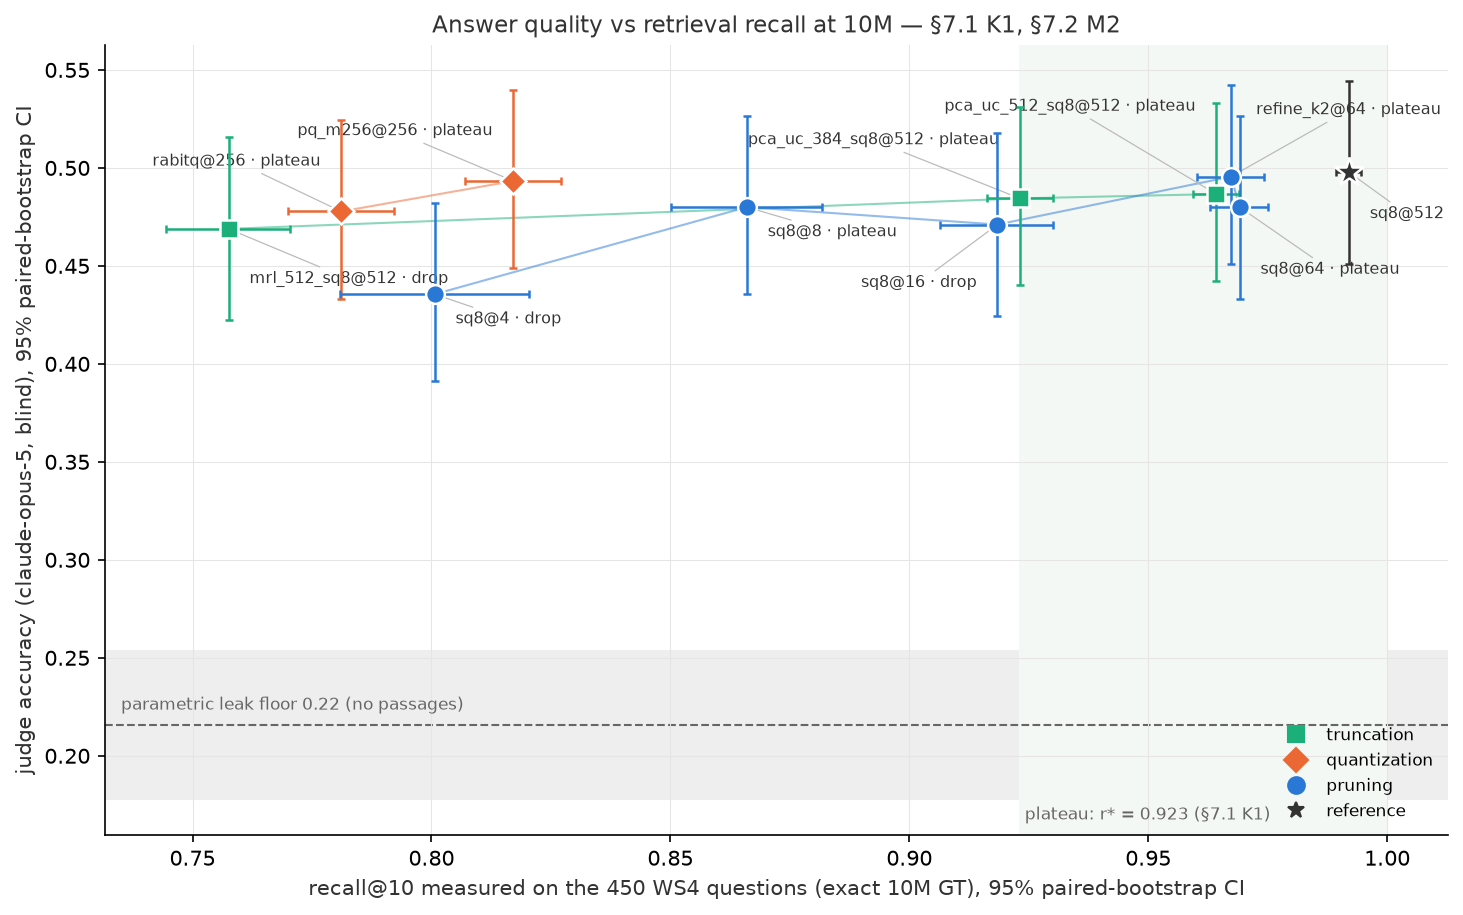

In [17]:
# ---- results/ws4/chart_quality_vs_recall.png --------------------------------
FAMILY_COLOR = {"truncation": "#1baf7a", "quantization": "#eb6834", "pruning": "#2a78d6",
                "reference": "#333333"}
FAMILY_MARKER = {"truncation": "s", "quantization": "D", "pruning": "o", "reference": "*"}
LABEL = lambda a: arms_df.set_index("arm_key").loc[a, "arm"]
# Labels: truncation above-right, pruning below-right, quantization above-left,
# reference above-left; within a family, alternate the vertical offset by
# recall rank so the dense high-recall cluster does not stack.
_FAM_OFF = {"truncation": [(-7, 9), (7, 22), (-7, 24)], "pruning": [(7, -14), (-7, -27), (7, -27), (-7, -14), (7, -40)],
            "quantization": [(-7, 9), (-7, 22)], "reference": [(10, 14)]}
def label_offsets(S):
    out = {}
    for famname, g in S.groupby("family"):
        for k, a in enumerate(g.sort_values("recall").arm):
            offs = _FAM_OFF[famname]; out[a] = offs[k % len(offs)]
    return out
def place(ax, r, text, offs, fontsize=7.5):
    dx, dy = offs[r.arm]
    ax.annotate(text, (r.recall, r.quality), textcoords="offset points", xytext=(dx, dy),
                fontsize=fontsize, color=INK, ha="left" if dx > 0 else "right",
                arrowprops=dict(arrowstyle="-", color="#bbbbbb", lw=0.6, shrinkA=0, shrinkB=4))
if complete_arms and REF in complete_arms:
    S = summary[(summary.metric == "judge") & (summary.arm != "parametric")]
    floor = summary[(summary.metric == "judge") & (summary.arm == "parametric")]
    fig, ax = plt.subplots(figsize=(10, 6.2), dpi=150)
    if len(floor):
        f = floor.iloc[0]
        ax.axhspan(f.quality_ci_lo, f.quality_ci_hi, color="#eeeeee", zorder=0)
        ax.axhline(f.quality, color=INK2, lw=1, ls="--", zorder=1)
        ax.text(0.012, f.quality + 0.008, f"parametric leak floor {f.quality:.2f} (no passages)",
                fontsize=8, color=INK2, transform=ax.get_yaxis_transform())
    # Hand-placed offsets for the dense high-recall cluster (the arm set is
    # fixed by arms.csv, so per-arm placement is legitimate, as in the WS2
    # chart); anything not listed falls back to the family rule.
    ARM_OFFSETS = {"sq8_np512": (10, -22), "sq8_np64": (10, -32), "refine_np64": (12, 30),
                   "pca_uc_512_sq8_np512": (-10, 40), "pca_uc_384_sq8_np512": (-10, 26),
                   "sq8_np16": (-10, -30), "sq8_np8": (10, -14), "sq8_np4": (10, -14),
                   "pq_np256": (-10, 22), "rabitq_np256": (-10, 22), "mrl_512_sq8_np512": (10, -26)}
    offs = {**label_offsets(S), **{a: o for a, o in ARM_OFFSETS.items() if a in set(S.arm)}}
    for _, r in S.sort_values("recall").iterrows():
        c, mk = FAMILY_COLOR[r.family], FAMILY_MARKER[r.family]
        ax.errorbar(r.recall, r.quality, xerr=[[r.recall - r.recall_ci_lo], [r.recall_ci_hi - r.recall]],
                    yerr=[[r.quality - r.quality_ci_lo], [r.quality_ci_hi - r.quality]],
                    fmt=mk, color=c, ms=9 if mk != "*" else 14, mec="white", mew=1.2, elinewidth=1.2,
                    capsize=2, zorder=4)
        cls = "" if r["class"] == "reference" else f" · {r['class'].lower()}"
        place(ax, r, f"{LABEL(r.arm)}{cls}", offs)
    for famname, c in FAMILY_COLOR.items():
        g = S[S.family == famname].sort_values("recall")
        if famname != "reference" and len(g) > 1:
            ax.plot(g.recall, g.quality, "-", color=c, lw=1, alpha=0.5, zorder=2)
    if r_star is not None:
        ax.axvspan(r_star, 1.0, color="#f4f8f4", zorder=0)
        ax.text(r_star, 0.02, f" plateau: r* = {r_star:.3f} (§7.1 {K})", fontsize=8, color=INK2,
                transform=ax.get_xaxis_transform())
    handles = [plt.Line2D([], [], marker=FAMILY_MARKER[f], ls="", color=c, ms=8, label=f)
               for f, c in FAMILY_COLOR.items()]
    ax.legend(handles=handles, frameon=False, fontsize=8, loc="lower right")
    ax.set_xlabel("recall@10 measured on the 450 WS4 questions (exact 10M GT), 95% paired-bootstrap CI", color=INK)
    ax.set_ylabel("judge accuracy (claude-opus-5, blind), 95% paired-bootstrap CI", color=INK)
    ax.set_title(f"Answer quality vs retrieval recall at 10M — §7.1 {K}, §7.2 {Mb}", color=INK, fontsize=11)
    ax.grid(True, color=GRID, lw=0.5, zorder=0)
    for s_ in ("top", "right"): ax.spines[s_].set_visible(False)
    fig.tight_layout(); fig.savefig(OUT / "chart_quality_vs_recall.png"); plt.show()
else:
    pending("headline chart")

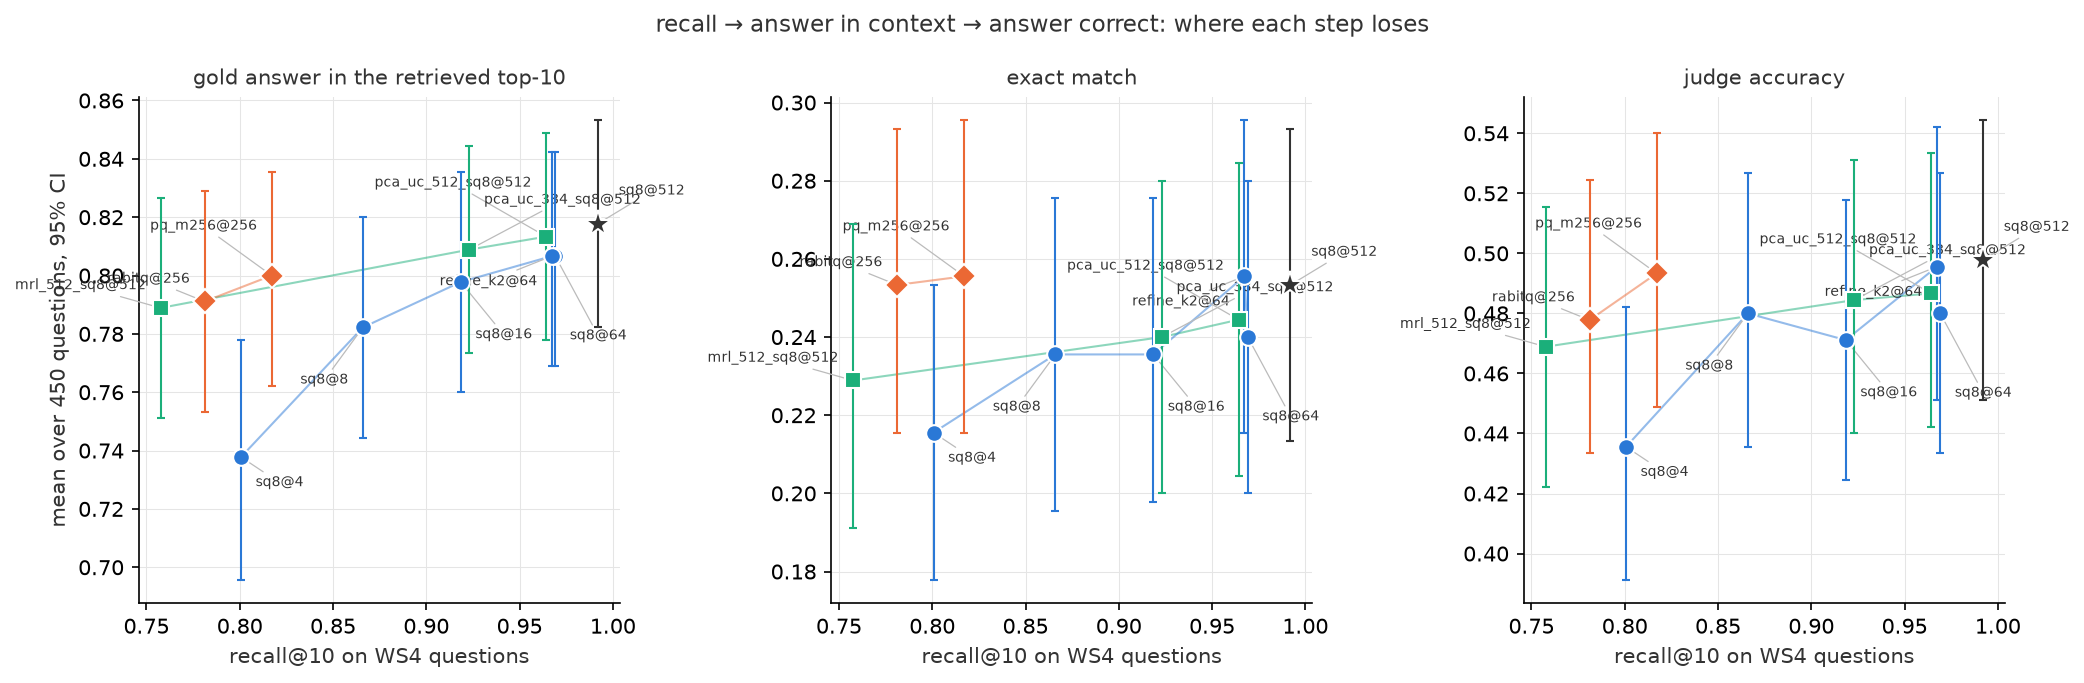

In [18]:
# ---- results/ws4/chart_mediator.png -----------------------------------------
if complete_arms and REF in complete_arms:
    panels = [("answer_presence_at_10", "gold answer in the retrieved top-10"),
              ("em", "exact match"), ("judge", "judge accuracy")]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), dpi=150, sharex=True)
    for ax, (metric, title) in zip(axes, panels):
        S = summary[(summary.metric == metric) & (summary.arm != "parametric")]
        for _, r in S.iterrows():
            c, mk = FAMILY_COLOR[r.family], FAMILY_MARKER[r.family]
            ax.errorbar(r.recall, r.quality, yerr=[[r.quality - r.quality_ci_lo], [r.quality_ci_hi - r.quality]],
                        fmt=mk, color=c, ms=8 if mk != "*" else 13, mec="white", mew=1, elinewidth=1, capsize=2, zorder=4)
            place(ax, r, LABEL(r.arm), label_offsets(S), fontsize=6.5)
        for famname, c in FAMILY_COLOR.items():
            g = S[S.family == famname].sort_values("recall")
            if famname != "reference" and len(g) > 1:
                ax.plot(g.recall, g.quality, "-", color=c, lw=1, alpha=0.5, zorder=2)
        ax.set_title(title, color=INK, fontsize=10); ax.grid(True, color=GRID, lw=0.5, zorder=0)
        ax.set_xlabel("recall@10 on WS4 questions", color=INK)
        for s_ in ("top", "right"): ax.spines[s_].set_visible(False)
    axes[0].set_ylabel("mean over 450 questions, 95% CI", color=INK)
    fig.suptitle("recall → answer in context → answer correct: where each step loses", color=INK, fontsize=11)
    fig.tight_layout(); fig.savefig(OUT / "chart_mediator.png"); plt.show()
else:
    pending("mediator chart")

## 10. Verdict summary — the paragraphs in results/recall-vs-quality.md come from here

In [19]:
# ---- verdicts keyed to spec §7 ----------------------------------------------
if complete_arms and REF in complete_arms:
    print("=" * 78); print("§7.1 THE KNEE (judge accuracy, paired bootstrap, margin 0.05)"); print("=" * 78)
    print(f"branch {K}; r* = {r_star}")
    for name, r, cls in sorted(knee_arms, key=lambda t: -t[1]):
        print(f"  {LABEL(name):<20} recall {r:.4f}  {cls}")
    print("\n" + "=" * 78); print("§7.2 THE MECHANISM"); print("=" * 78)
    print(f"branch {Mb}")
    for r in PJ.itertuples():
        tag = "primary/face" if r.pair == "A" else "adjusted"
        ci = (r.face_lo, r.face_hi) if r.pair == "A" else (r.adj_lo, r.adj_hi)
        print(f"  {r.pair}: {LABEL(r.first)} − {LABEL(r.second)} = {r.diff:+.4f} "
              f"[{ci[0]:+.4f}, {ci[1]:+.4f}] ({tag}) matched={r.matched} gap={r.recall_gap:.4f}")
    print("\n§7.5 parametric floor:", end=" ")
    if len(floor):
        print(f"{floor.iloc[0].quality:.4f} -> {core.parametric_reading(floor.iloc[0].quality)}; "
              f"leak-adjusted §7.1: {K_leak}, r* = {r_star_leak}")
    print(f"§3.1 filter rate: {qf.filter_rate.iloc[0]:.4f} ({qf.n_pass_at_100.iloc[0]}/{qf.n_validation.iloc[0]})")
    print(f"spend: ${spend:.2f} of ${WS4_BUDGET_USD:.2f} (+ reliability re-run "
          f"${rel.cost_total_billed.sum() if rl else 0:.2f})")
    print(f"idk rate by arm:\n{runs[runs.subset=='main'].groupby('arm').idk.mean().round(3).to_string()}")
if PENDING:
    print("\nSTILL PENDING:\n  - " + "\n  - ".join(PENDING))
else:
    manifest.record_meta("nb04_completed", time.strftime("%Y-%m-%dT%H:%M:%S"))
    print("\nnotebook complete — no pending cells")

§7.1 THE KNEE (judge accuracy, paired bootstrap, margin 0.05)
branch K1; r* = 0.9231111111111113
  sq8@64               recall 0.9691  PLATEAU
  refine_k2@64         recall 0.9673  PLATEAU
  pca_uc_512_sq8@512   recall 0.9642  PLATEAU
  pca_uc_384_sq8@512   recall 0.9231  PLATEAU
  sq8@16               recall 0.9184  DROP
  sq8@8                recall 0.8660  PLATEAU
  pq_m256@256          recall 0.8171  PLATEAU
  sq8@4                recall 0.8007  DROP
  rabitq@256           recall 0.7811  PLATEAU
  mrl_512_sq8@512      recall 0.7576  DROP

§7.2 THE MECHANISM
branch M2
  A: pca_uc_512_sq8@512 − refine_k2@64 = -0.0089 [-0.0356, +0.0178] (primary/face) matched=True gap=0.0031
  B: pca_uc_512_sq8@512 − sq8@64 = +0.0067 [-0.0244, +0.0400] (adjusted) matched=True gap=0.0049
  C: pca_uc_384_sq8@512 − sq8@16 = +0.0133 [-0.0244, +0.0511] (adjusted) matched=True gap=0.0047
  D: mrl_512_sq8@512 − sq8@4 = +0.0333 [-0.0133, +0.0800] (adjusted) matched=False gap=0.0431
  E: pq_m256@256 − sq8@8 = 